<a href="https://www.kaggle.com/code/dmytrokan/notebookd716754039?scriptVersionId=356750366" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
from torchvision import datasets, transforms

In [2]:
paths = "/kaggle/input/datasets/sshikamaru/fruit-recognition/train/train"

In [3]:
dataset = datasets.ImageFolder(paths)

In [4]:
img, label = dataset[30]

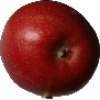

In [5]:
img

In [6]:
label

0

In [7]:
dataset.classes[label]

'Apple Braeburn'

In [8]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

In [9]:
from torchvision import transforms
train_transformer = transforms.Compose([
       transforms.Resize([128, 128]), 
       transforms.RandomHorizontalFlip(p=0.5),  
       transforms.RandomRotation(10),   
       transforms.ToTensor()  
])

test_transformer = transforms.Compose([
       transforms.Resize([128, 128]),
       transforms.ToTensor()
])

In [10]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [11]:
train_dataset = TransformDataset(train_dataset, train_transformer)
test_dataset = TransformDataset(test_dataset, test_transformer)

In [12]:
len(dataset.classes)

33

In [13]:
from torch.utils.data import Dataset,DataLoader

In [14]:
train_loader = DataLoader(train_dataset, batch_size = 120)
test_loader = DataLoader(test_dataset, batch_size = 120)

In [15]:
from torch import nn
128 * 128 * 3

49152

In [16]:
model = nn.Sequential(
    nn.Flatten(),  
    nn.Linear(49152, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 50),
    nn.ReLU(),
    nn.Linear(50, 33)   
)

In [17]:
from torch.optim import Adam

loss_fn = nn.CrossEntropyLoss()

optimizer = Adam(
    model.parameters(),
    lr=0.001,
)

In [18]:
epochs = 1
train_lost = []
test_lost = []
for _ in range(epochs):
    for X_batch, y_batch in train_loader:
    
        y_pred = model(X_batch)
    
        loss = loss_fn(y_pred, y_batch)
        train_lost.append(loss.item())
        print(loss.item())
    
        optimizer.zero_grad()   
        loss.backward()        
        optimizer.step() 
        
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)

        loss = loss_fn(y_pred, y_batch)
        test_lost.append(loss.item())

3.4857065677642822
5.284789085388184
4.266355037689209
3.9279892444610596
3.7582406997680664
3.650073528289795
3.4773690700531006
3.4640870094299316
3.414034843444824
3.39935040473938
3.328568458557129
3.366379737854004
3.3999381065368652
3.194932699203491
3.1961464881896973
3.25748872756958
3.0564358234405518
2.9779675006866455
3.0602447986602783
2.940082311630249
3.009446144104004
2.839216947555542
2.7693188190460205
2.8400750160217285
2.8296334743499756
2.791506290435791
2.9200544357299805
2.830287218093872
2.6250405311584473
2.6365344524383545
2.6666979789733887
2.485840320587158
2.592747449874878
2.5845136642456055
2.4251134395599365
2.5069403648376465
2.3193016052246094
2.36797833442688
2.4701335430145264
2.4556095600128174
2.400390386581421
2.4583327770233154
2.2858195304870605
2.1253905296325684
1.9902117252349854
2.2434816360473633
2.004337787628174
2.0783400535583496
1.958335280418396
1.9048421382904053
1.9337372779846191
1.9977614879608154
1.7732676267623901
1.74363291263580

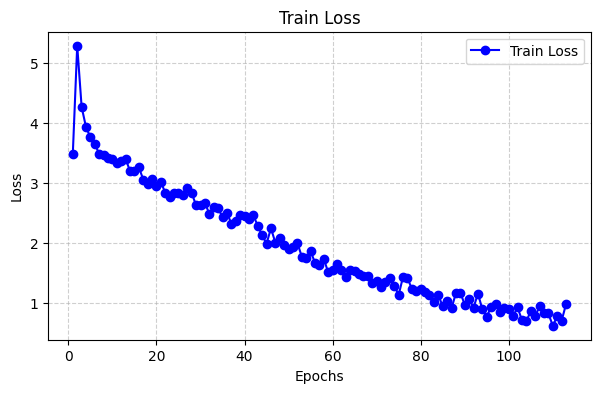

In [19]:

import matplotlib.pyplot as plt
step = range(1, len(train_lost) + 1)

# График 1: Train Loss
plt.figure(figsize=(7, 4))
plt.plot(step, train_lost, label='Train Loss', color='blue', marker='o')
plt.title('Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

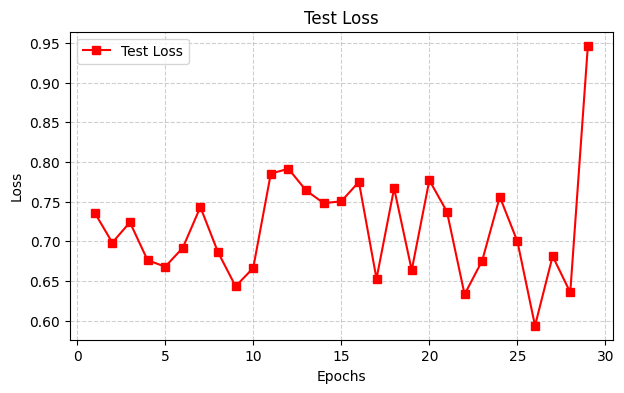

In [20]:

step_test = range(1, len(test_lost) + 1)
# График 2: Test Loss
plt.figure(figsize=(7, 4))
plt.plot(step_test, test_lost, label='Test Loss', color='red', marker='s')
plt.title('Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()